In [1]:
from neuprint import Client, fetch_neurons, fetch_adjacencies, NeuronCriteria as NC
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()  # Load environment variables from .env file
client = Client('neuprint.janelia.org', dataset='male-cns:v1.0', token=os.environ['NEUPRINT_TOKEN'])

In [2]:
# Conceptual neurons: R -> L1 -> L2 -> Mi1 -> Tm3 -> Tm1 -> Tm2 -> T4 -> T5
# R = R1-R6 photoreceptor neurons
    # due to neural superposition, R1-R6 from neighboring facets converge onto the same L1 and L2 neurons, so pool/average the connection
    # converts light hitting the eye into an electrical signal -> brighter light = suppresses firing of L1 and L2 neurons
# L1/L2 = L1 and L2 lamina neurons
    # excited by darkness and inhibited by light
    # carry the same signal but along a split -> L1 preferentially feeds neurons that track brightness increase (ON pathway)
    # while L2 preferentially feeds neurons that track brightness decrease (OFF pathway)
# Mi1/Tm3 = Mi1 and Tm3 medulla neurons
    # Continue the ON pathway from L1 and end up tuned to brightness increases
    # main inputs into T4, and don't behave identically in time - one carries a more delayed signal
# Tm1/Tm2 = Tm1 and Tm2 medulla neurons
    # Continue the OFF pathway from L2 and end up tuned to brightness decreases
# T4/T5 = T4 and T5 lobula plate neurons
    # The actual direction-selective outputs. T4 compares its ON-pathway inputs across neighboring columns to detect moving brightness increases
    # T5 compares its OFF-pathway inputs across neighboring columns to detect moving brightness decreases

lamina_neurons, lamina_roi_counts = fetch_neurons(NC(inputRois=['LA(R)']))
medulla_neurons, medulla_roi_counts = fetch_neurons(NC(inputRois=['ME(R)']))
lobula_neurons, lobula_roi_counts = fetch_neurons(NC(inputRois=['LO(R)']))

In [3]:
lamina_neurons_filtered = lamina_neurons[lamina_neurons['type'].isin(['R1-R6', 'L1', 'L2'])]
medulla_neurons_filtered = medulla_neurons[medulla_neurons['type'].isin(['Mi1', 'Tm3', 'Tm1', 'Tm2'])]
medulla_neurons_filtered_t4 = medulla_neurons[medulla_neurons['type'].str.contains('T4', na=False)]
medulla_neurons_filtered_t4['type'] = 'T4'
medulla_neurons_filtered = pd.concat([medulla_neurons_filtered, medulla_neurons_filtered_t4])
lobula_neurons_filtered = lobula_neurons[lobula_neurons['type'].str.contains('^T5', na=False)]
lobula_neurons_filtered['type'] = 'T5'

In [4]:
all_neurons = pd.concat([lamina_neurons_filtered, medulla_neurons_filtered, lobula_neurons_filtered])
combined_ids = all_neurons['bodyId'].tolist()
all_neurons_df, all_connections_df = fetch_adjacencies(sources=combined_ids, targets=combined_ids)

  0%|          | 0/72 [00:00<?, ?it/s]

0it [00:00, ?it/s]

In [5]:
all_connections_df = all_connections_df.merge(all_neurons, left_on='bodyId_pre', right_on='bodyId', how='left') \
    .drop(columns='bodyId') \
    .rename(columns={'type': 'type_pre'})

all_connections_df = all_connections_df.merge(all_neurons, left_on='bodyId_post', right_on='bodyId', how='left') \
    .drop(columns='bodyId') \
    .rename(columns={'type': 'type_post'})

type_matrix = all_connections_df.pivot_table(index='type_pre', columns='type_post', values='weight', aggfunc='mean', fill_value=0)

In [6]:
type_matrix

type_post,L1,L2,Mi1,R1-R6,T4,T5,Tm1,Tm2,Tm3
type_pre,,,,,,,,,
L1,2.571429,2.122137,64.945550,1.437781,1.000000,0.000000,1.263158,2.466667,12.514577
L2,2.660819,1.588235,1.902335,2.570414,0.000000,0.000000,105.623884,74.319069,1.691983
Mi1,17.166667,1.403226,2.407220,0.000000,9.571566,0.000000,2.308153,1.548951,9.624327
R1-R6,28.617785,29.493790,0.000000,1.971963,0.000000,0.000000,0.000000,0.000000,0.000000
T4,1.333333,0.000000,1.094763,0.000000,1.970204,1.542112,1.121622,1.130000,1.139276
T5,0.000000,0.000000,3.000000,0.000000,1.499310,1.839656,1.083077,1.077273,1.069444
Tm1,1.000000,2.097770,1.567141,0.000000,1.295567,4.900804,1.612903,2.599219,1.368254
Tm2,1.846154,2.139860,1.690691,0.000000,1.587629,7.077178,2.738865,1.452830,1.449036
Tm3,3.496896,1.687500,2.124469,0.000000,5.121641,1.492635,1.432900,1.437811,3.111661


In [7]:
type_matrix = type_matrix.reindex(index=['R1-R6', 'L1', 'L2', 'Mi1', 'Tm3', 'Tm1', 'Tm2', 'T4', 'T5'], columns=['R1-R6', 'L1', 'L2', 'Mi1', 'Tm3', 'Tm1', 'Tm2', 'T4', 'T5'], fill_value=0)
type_matrix.to_csv('type_matrix.csv')

In [8]:
# R (R1-R6): histamine -> inhibitory
# Known biology: R depolarizes in response to light and releases MORE histamine,
# which is inhibitory on its targets -> brighter light suppresses downstream cells.

# L1: glutamate -> inhibitory
# Literature-confirmed for this specific circuit (Molina-Obando et al. 2019, eLife):
# L1's glutamate is used as an inhibitory synapse onto Mi1/Tm3, providing the sign
# inversion needed so the ON pathway ends up excited by light increases (double
# negative: R inhibits L1, L1 inhibits Mi1/Tm3 -> net positive).

# L2: acetylcholine -> excitatory
# Standard ACh convention. Notably DIFFERENT sign-mechanism from L1 (glutamate/
# inhibitory) despite both being suppressed by R identically -- this difference is
# exactly what splits one shared R input into the ON and OFF pathways.

# Mi1 / Tm3: acetylcholine -> excitatory
# Standard ACh convention. Continue the ON pathway from L1.

# Tm1 / Tm2: acetylcholine -> excitatory
# Standard ACh convention. Continue the OFF pathway from L2.

# T4: acetylcholine -> excitatory
# Dominant type by far (3438 ACh vs 1 GABA) -- single GABA neuron treated as noise,
# not a real minority population.

# T5: acetylcholine -> excitatory
# Dominant type by far (3356 ACh vs 1 "unclear") -- same noise-vs-signal reasoning as T4.


sign_matrix = [-1, -1, 1, 1, 1, 1, 1, 1, 1]
sign_matrix = pd.DataFrame(sign_matrix, index=['R1-R6', 'L1', 'L2', 'Mi1', 'Tm3', 'Tm1', 'Tm2', 'T4', 'T5'], columns=['sign'])
sign_matrix.to_csv('sign_matrix.csv')

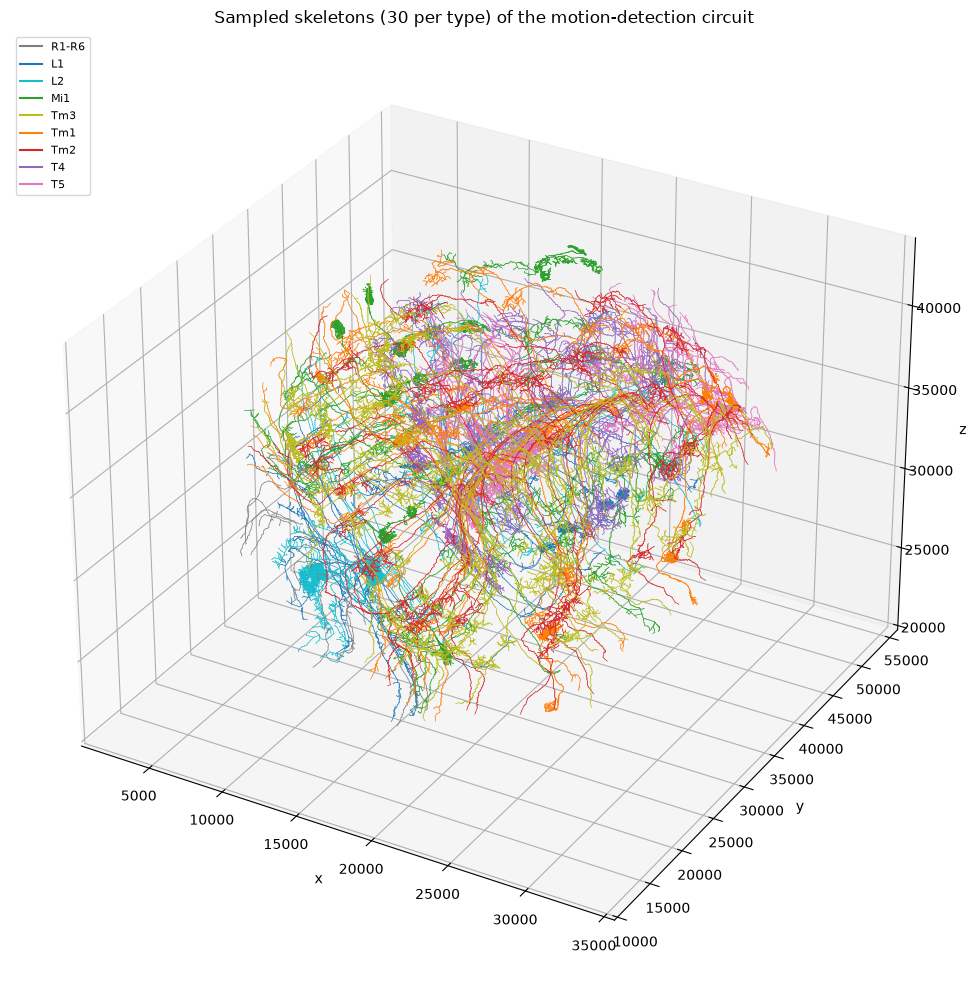

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers the '3d' projection

TYPE_COLORS = {
    'R1-R6': 'tab:gray',
    'L1': 'tab:blue',
    'L2': 'tab:cyan',
    'Mi1': 'tab:green',
    'Tm3': 'tab:olive',
    'Tm1': 'tab:orange',
    'Tm2': 'tab:red',
    'T4': 'tab:purple',
    'T5': 'tab:pink',
}

SAMPLE_PER_TYPE = 30  # fetching every neuron (especially R1-R6, hundreds of cells) is slow and overplots - sample a representative handful per type instead

# a plain loop instead of groupby().apply() - newer pandas can silently drop the grouping
# column ('type') from what's passed into an apply() lambda, which breaks row['type'] below
sampled = pd.concat([
    group.sample(min(len(group), SAMPLE_PER_TYPE), random_state=0)
    for _, group in all_neurons.groupby('type')
])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for _, row in sampled.iterrows():
    body_id = row['bodyId']
    neuron_type = row['type']
    skeleton = client.fetch_skeleton(body_id, heal=True)  # columns: rowId, x, y, z, radius, link (link = parent rowId, -1 for root)
    skeleton = skeleton.set_index('rowId')

    for row_id, node in skeleton.iterrows():
        parent_id = node['link']
        if parent_id == -1 or parent_id not in skeleton.index:
            continue
        parent = skeleton.loc[parent_id]
        ax.plot(
            [node['x'], parent['x']],
            [node['y'], parent['y']],
            [node['z'], parent['z']],
            color=TYPE_COLORS.get(neuron_type, 'black'),
            linewidth=0.5,
        )

# build the legend manually since each type is drawn as many small line segments, not one labeled object
handles = [plt.Line2D([0], [0], color=color, label=t) for t, color in TYPE_COLORS.items() if t in sampled['type'].unique()]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title(f"Sampled skeletons ({SAMPLE_PER_TYPE} per type) of the motion-detection circuit")
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()